In [2]:
import json
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer  # For baseline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer  # For semantic embeddings
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords

import os
os.getcwd()

c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'c:\\Users\\hmhol\\Python scripts\\Psalms'

# Biblical psalm verses theme extraction

Let's take our psalms json which I've already scraped and cleaned from biblehub. The JSON contains psalm/verse, the text of the verse, and a set of scores indicating sentiment from VADER. The goal is to group the psalms by their semantic value via vectorizing the words, then applying k-means clustering.

In [7]:
def load_ps_dict(filename='./ps_dict_with_sentiment_v2.json'):
    """Load psalm dictionary from JSON file."""
    with open(filename, 'r', encoding='utf-8') as f:
        return json.load(f)

In [39]:
ps_dict = load_ps_dict()
#ps_dict

In [9]:
#Pull the relevant info into a dataframe
verses = []
for psalm, verse_list in ps_dict.items():
    for verse in verse_list:
        verses.append({
            'psalm': psalm,
            'verse_number': verse['verse_number'],
            'text': verse['text'],
            'compound_sentiment': verse['sentiment']['compound']
        })

df = pd.DataFrame(verses)
df.head()

,psalm,verse_number,text,compound_sentiment
0,1,1,Happy are those who do not follow the advice o...,0.0772
1,1,2,"but their delight is in the law of the Lord, a...",0.7469
2,1,3,They are like trees planted by streams of wate...,0.3612
3,1,4,"The wicked are not so, but are like chaff that...",0.2617
4,1,5,Therefore the wicked will not stand in the jud...,-0.5267


In [10]:
df.shape

(2457, 4)

## Preprocessing for text vectorization

Here we'll remove stopwords, convert to lower, stem and tokenize the words in the text. Lastly we'll join them back together and append to the dataset.

In [11]:
# Step 2: Preprocess/Text Cleaning (Light for semantic embeddings)
stop_words = set(stopwords.words('english'))
def preprocess(text):
    # Simple tokenization and cleaning
    tokens = nltk.word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalnum() and t not in stop_words]
    return ' '.join(tokens)  # Rejoin for sentence-level input

df['clean_text'] = df['text'].apply(preprocess)

In [12]:
df.head()

,psalm,verse_number,text,compound_sentiment,clean_text
0,1,1,Happy are those who do not follow the advice o...,0.0772,happy follow advice wicked take path sinners t...
1,1,2,"but their delight is in the law of the Lord, a...",0.7469,delight law lord law meditate day night
2,1,3,They are like trees planted by streams of wate...,0.3612,like trees planted streams water yield fruit s...
3,1,4,"The wicked are not so, but are like chaff that...",0.2617,wicked like chaff wind drives away
4,1,5,Therefore the wicked will not stand in the jud...,-0.5267,therefore wicked stand judgment sinners congre...


## Vectorizing

Here we use a BERT-like transformer to vectorize the cleaned up text

In [13]:
# Step 3: Vectorization
# Option A: TF-IDF Baseline (non-semantic)
# vectorizer = TfidfVectorizer(max_features=5000)  # Limit dims for efficiency
# embeddings = vectorizer.fit_transform(df['clean_text']).toarray()

# Option B: Semantic Embeddings 
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(df['clean_text'].tolist(), show_progress_bar=True)  

# Optional: Dimensionality Reduction
pca = PCA(n_components=50)  
embeddings_reduced = pca.fit_transform(embeddings)

Batches: 100%|██████████| 77/77 [00:03<00:00, 19.88it/s]


## Clustering

Lastly we'll apply k-means to cluster the embedding

In [14]:
# Step 4: Clustering with K-Means
os.environ['LOKY_MAX_CPU_COUNT'] = '8'  # Limit CPU usage for large datasets

n_clusters = 5 # Shot in the dark here - adjust later as needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(embeddings_reduced)

# Evaluate (optional)
sil_score = silhouette_score(embeddings_reduced, df['cluster'])
print(f'Silhouette Score: {sil_score}') 

Silhouette Score: 0.044750064611434937


## Final results

The silhouette score from the k-means output was very poor. This likely reflects the difficulty of grouping together the winding, poetic verses of the psalms. The embedding plot is particularly poor. The clusters clearly run into each other - although there may be variation in the higher dimensions that doesn't get reflected here. 

That said, the groups of the verses have clear themes. I've offered the following for each group:

- Cluster 0: **Hopefulness** (Mean sentiment: +0.56, Size: 381) – Personal trust, gladness, and divine love amid challenges.
- Cluster 1: **Poetic Metaphors** (Mean: +0.04, Size: 592) – Vivid imagery of prosperity, conflict, and natural contrasts.
- Cluster 2: **Protection & Authority** (Mean: +0.23, Size: 253) – God's kingship, heritage, and strongholds for the oppressed.
- Cluster 3: **Judgment & Righteousness** (Mean: -0.20, Size: 553) – Moral paths, wrath on the wicked, and calls for refuge.
- Cluster 4: **Victory & Power** (Mean: +0.32, Size: 678) – Divine decrees, mockery of enemies, and affirmations of power.


Cluster 0 (Size: 381)
Sample Verses: ['many are saying to me, “There is no help for you in God.”Selah'
 'How long, you people, shall my honor suffer shame? How long will you love vain words, and seek after lies?Selah'
 'Offer right sacrifices, and put your trust in the Lord.'
 'You have put gladness in my heart more than when their grain and wine abound.'
 'But I, through the abundance of your steadfast love, will enter your house, I will bow down toward your holy temple in awe of you.']

Cluster 1 (Size: 592)
Sample Verses: ['They are like trees planted by streams of water, which yield their fruit in its season, and their leaves do not wither. In all that they do, they prosper.'
 'The wicked are not so, but are like chaff that the wind drives away.'
 '“Let us burst their bonds asunder, and cast their cords from us.”'
 'You shall break them with a rod of iron, and dash them in pieces like a potter’s vessel.”'
 'I am not afraid of ten thousands of people who have set themselves against

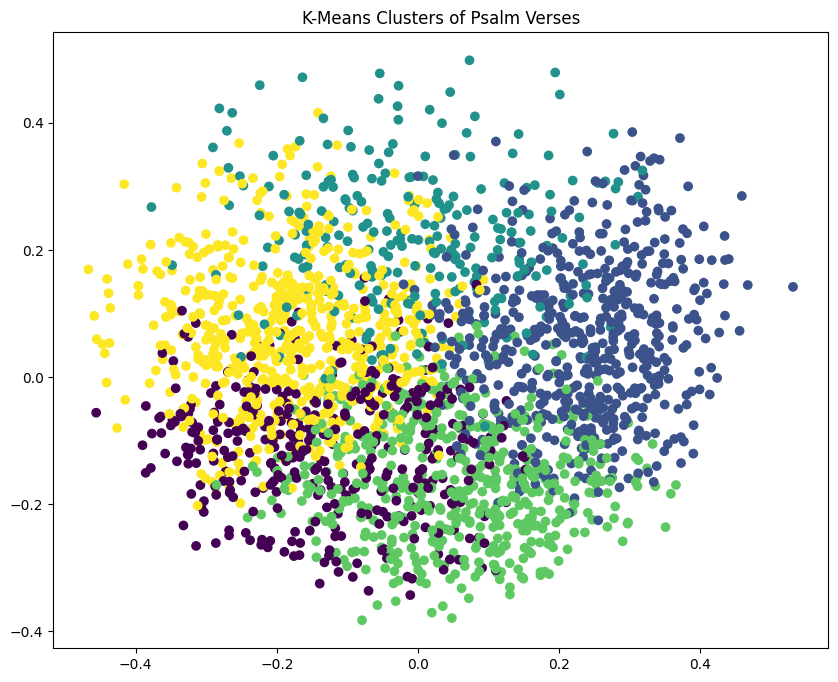

In [15]:
# Step 5: Analyze Clusters for Topic Labels
# Group by cluster and inspect top texts/words
for cluster in range(n_clusters):
    cluster_df = df[df['cluster'] == cluster]
    print(f'\nCluster {cluster} (Size: {len(cluster_df)})')
    print('Sample Verses:', cluster_df['text'].head(5).values)

# Viz: Scatter plot of reduced embeddings colored by cluster
plt.figure(figsize=(10, 8))
plt.scatter(embeddings_reduced[:, 0], embeddings_reduced[:, 1], c=df['cluster'], cmap='viridis')
plt.title('K-Means Clusters of Psalm Verses')
plt.show()

In [16]:
df.groupby('cluster')['compound_sentiment'].agg(['mean', 'count'])

,mean,count
cluster,,
0,0.556204,381
1,0.037703,592
2,0.226674,253
3,-0.192317,553
4,0.317691,678


In [ ]:
# Updated mapping based on new cluster content
cluster_labels = {
    0: 'Hopefulness',
    1: 'Poetic Metaphors',
    2: 'Protection and Authority',
    3: 'Judgment & Righteousness',
    4: 'Victory and Power'
}

# Add/overwrite the label column
df['cluster_label'] = df['cluster'].map(cluster_labels)

df.to_csv('psalms_with_clusters_updated.csv', index=False)

print("Updated labels applied and exported to psalms_with_clusters_updated.csv!")

Updated labels applied and exported to psalms_with_clusters_updated.csv!


## Version #2: Normalizing embedding and using cosine similarity + UMAP instead of PCA

The first steps follow as before up to the embeddings

In [ ]:
#Pull the relevant info into a dataframe
verses = []
for psalm, verse_list in ps_dict.items():
    for verse in verse_list:
        verses.append({
            'psalm': psalm,
            'verse_number': verse['verse_number'],
            'text': verse['text'],
            'compound_sentiment': verse['sentiment']['compound']
        })

df = pd.DataFrame(verses)

# Step 2: Preprocess/Text Cleaning (Light for semantic embeddings)
stop_words = set(stopwords.words('english'))
def preprocess(text):
    # Simple tokenization and cleaning
    tokens = nltk.word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalnum() and t not in stop_words]
    return ' '.join(tokens)  # Rejoin for sentence-level input

df['clean_text'] = df['text'].apply(preprocess)

# Semantic Embeddings 
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(df['clean_text'].tolist(), show_progress_bar=True)  

Now let's normalize the embeddings using the L2 norm

In [19]:
from sklearn.preprocessing import normalize

# Normalize to unit length (for cosine)
embeddings_norm = normalize(embeddings)

In [20]:
import umap

# For clustering: Reduce to 50 dims (tune as needed; UMAP is flexible)
umap_model = umap.UMAP(n_components=50, n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embeddings_reduced = umap_model.fit_transform(embeddings_norm)  # Use normalized for cosine metric

# Separate 2D reduction for viz (optional, but helps see structure)
umap_2d = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embeddings_2d = umap_2d.fit_transform(embeddings_norm)

c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


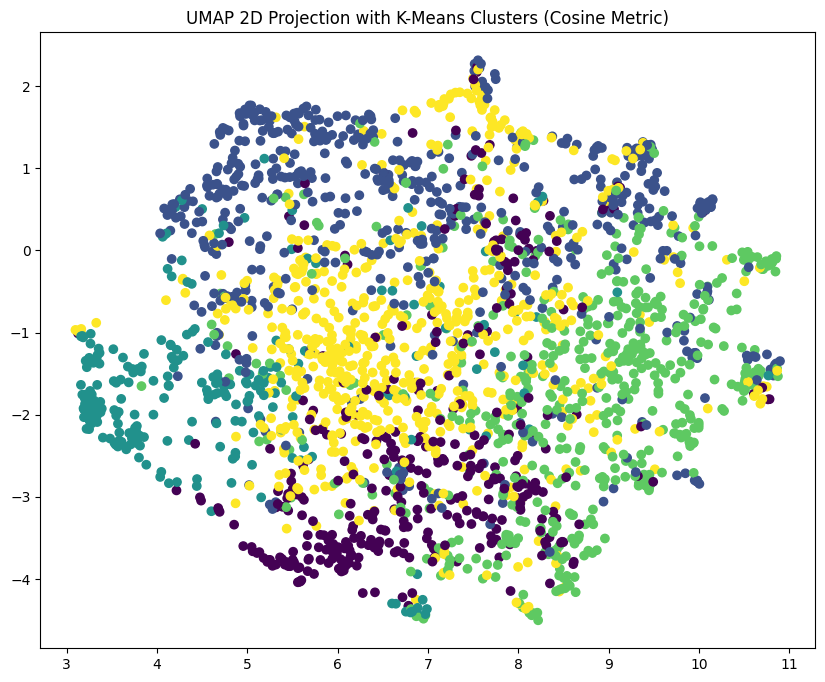

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=df['cluster'], cmap='viridis')
plt.title('UMAP 2D Projection with K-Means Clusters (Cosine Metric)')
plt.show()

The first UMAP embedding looks really bad - but there are clearly some regions where the verses are clumping. Let's see if we can improve this. Here's a simple grid tightening up some of the hyperparameters. A higher # of epochs and a lower min_dist usually helps.

c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Params {'n_neighbors': 15, 'min_dist': 0.01, 'n_epochs': 500}: Cosine Silhouette = 0.01613108441233635


c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Params {'n_neighbors': 10, 'min_dist': 0.001, 'n_epochs': 1000}: Cosine Silhouette = 0.018941465765237808


c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Params {'n_neighbors': 30, 'min_dist': 0.05, 'n_epochs': 500}: Cosine Silhouette = 0.024340225383639336


c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Best Params {'n_neighbors': 30, 'min_dist': 0.05, 'n_epochs': 500} - Final Cosine Silhouette: 0.024340225383639336


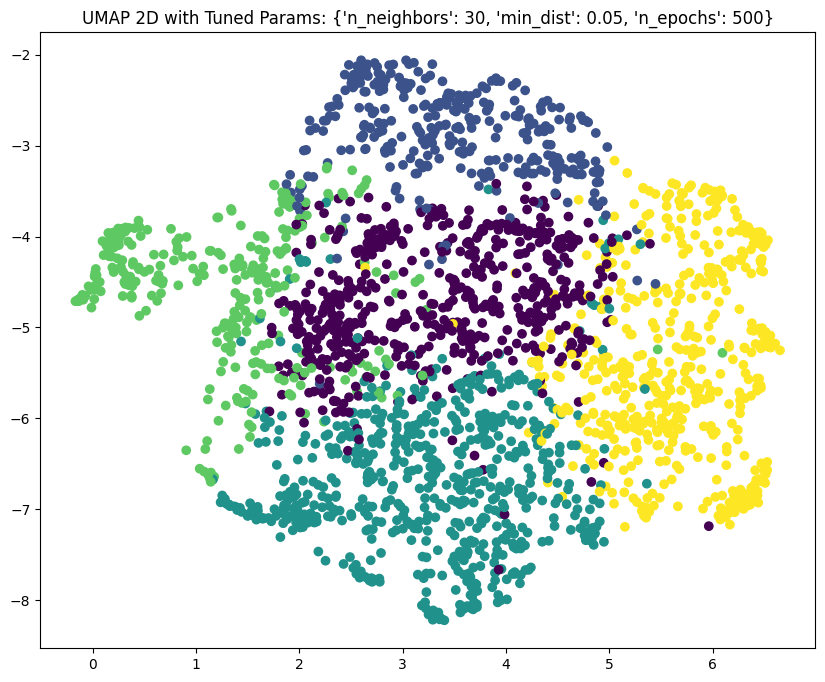


Cluster 0 (Size: 569)
Sample Verses: ['He who sits in the heavens laughs; the Lord has them in derision.'
 'I will tell of the decree of the Lord: He said to me, “You are my son; today I have begotten you.'
 'many are saying to me, “There is no help for you in God.”Selah'
 'But you, O Lord, are a shield around me, my glory, and the one who lifts up my head.'
 'I cry aloud to the Lord, and he answers me from his holy hill.Selah']

Cluster 1 (Size: 318)
Sample Verses: ['They are like trees planted by streams of water, which yield their fruit in its season, and their leaves do not wither. In all that they do, they prosper.'
 'The wicked are not so, but are like chaff that the wind drives away.'
 'When I look at your heavens, the work of your fingers, the moon and the stars that you have established;'
 'all sheep and oxen, and also the beasts of the field,'
 'the birds of the air, and the fish of the sea, whatever passes along the paths of the seas.']

Cluster 2 (Size: 686)
Sample Verses:

In [24]:
# Param tuning loop (test a few combos)
param_combos = [
    {'n_neighbors': 15, 'min_dist': 0.01, 'n_epochs': 500},  # Tighter, more iterations
    {'n_neighbors': 10, 'min_dist': 0.001, 'n_epochs': 1000},  # Even tighter, max iterations
    {'n_neighbors': 30, 'min_dist': 0.05, 'n_epochs': 500},   # Broader, moderate tight
]

best_sil = -1
best_reduced = None
best_params = None
best_2d = None

for params in param_combos:
    # UMAP for clustering (50 dims)
    umap_model = umap.UMAP(
        n_components=50,
        metric='cosine',
        random_state=42,
        **params
    )
    reduced = umap_model.fit_transform(embeddings_norm)
    
    # Quick cluster to eval
    kmeans_temp = KMeans(n_clusters=5, random_state=42)
    labels_temp = kmeans_temp.fit_predict(reduced)
    sil_temp = silhouette_score(embeddings_norm, labels_temp, metric='cosine')
    print(f"Params {params}: Cosine Silhouette = {sil_temp}")
    
    if sil_temp > best_sil:
        best_sil = sil_temp
        best_reduced = reduced
        best_params = params
        
        # Compute 2D viz for the best
        umap_2d = umap.UMAP(
            n_components=2,
            metric='cosine',
            random_state=42,
            **params
        )
        best_2d = umap_2d.fit_transform(embeddings_norm)

# Use best for final clustering
if best_reduced is not None:
    kmeans = KMeans(n_clusters=5, random_state=42)
    df['cluster'] = kmeans.fit_predict(best_reduced)
    final_sil = silhouette_score(embeddings_norm, df['cluster'], metric='cosine')
    print(f"Best Params {best_params} - Final Cosine Silhouette: {final_sil}")
    
    # Viz the best 2D
    plt.figure(figsize=(10, 8))
    plt.scatter(best_2d[:, 0], best_2d[:, 1], c=df['cluster'], cmap='viridis')
    plt.title(f'UMAP 2D with Tuned Params: {best_params}')
    plt.show()

# Re-inspect clusters as before
for cluster in range(5):
    cluster_df = df[df['cluster'] == cluster]
    print(f'\nCluster {cluster} (Size: {len(cluster_df)})')
    print('Sample Verses:', cluster_df['text'].head(5).values)

In [25]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

# Assuming embeddings_norm, embeddings_reduced, and df['cluster'] from your tuned run

# Silhouette on reduced (Euclidean, for comparison)
sil_reduced_euc = silhouette_score(embeddings_reduced, df['cluster'], metric='euclidean')
print(f'Euclidean Silhouette on Reduced: {sil_reduced_euc}')

# Davies-Bouldin (on reduced, Euclidean)
db_score = davies_bouldin_score(embeddings_reduced, df['cluster'])
print(f'Davies-Bouldin Score: {db_score}')  # Aim <1 for decent clustering

# Calinski-Harabasz (on reduced, Euclidean)
ch_score = calinski_harabasz_score(embeddings_reduced, df['cluster'])
print(f'Calinski-Harabasz Score: {ch_score}')  # Higher better, no fixed threshold

# K-means Inertia (from your kmeans object)
print(f'Inertia: {kmeans.inertia_}')  # Lower better; compare across runs

Euclidean Silhouette on Reduced: 0.2241412103176117
Davies-Bouldin Score: 1.4703375515882102
Calinski-Harabasz Score: 623.311767578125
Inertia: 2841.570068359375


Now that embedding looks much better! Let's try to make this even better by 
- increasing n_epochs 
- reducing min_dist 
- reducing n_components for the clustering dimension to avoid the curse of dimensionality

Then we'll apply HDBSCAN for clustering.

c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Cosine Silhouette: 0.012091806158423424
Euclidean Silhouette on Reduced: 0.24618542194366455
Davies-Bouldin: 1.4064400372259087
Calinski-Harabasz: 682.6734008789062
Inertia: 5418.04736328125


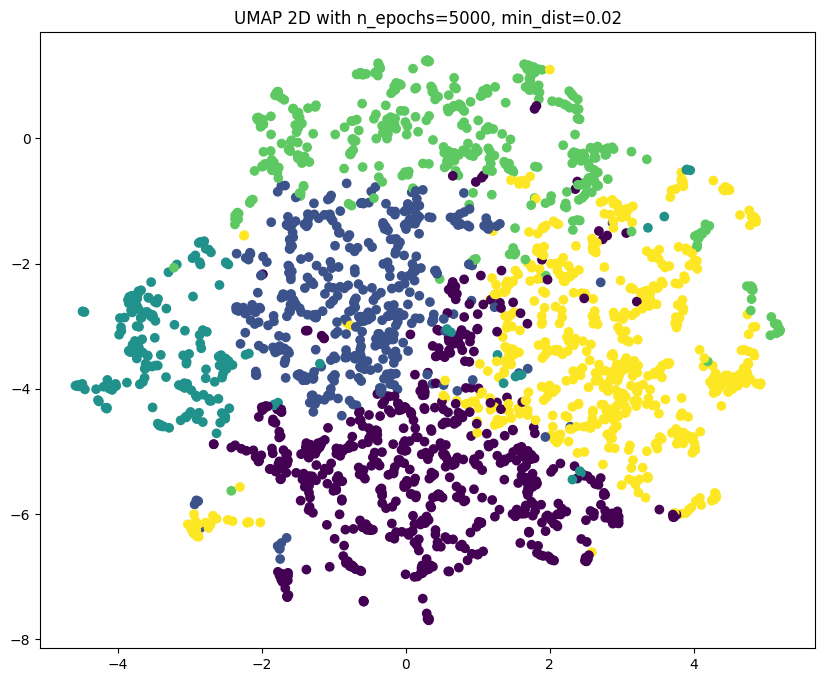

c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Euclidean Silhouette (valid): 0.42638060450553894
Davies-Bouldin (valid): 1.0165563937988864
Calinski-Harabasz (valid): 615.3704833984375
Detected 15 clusters (excluding noise)

Cluster 0 (Size: 185)
Sample Verses: ['They are like trees planted by streams of water, which yield their fruit in its season, and their leaves do not wither. In all that they do, they prosper.'
 '“Let us burst their bonds asunder, and cast their cords from us.”'
 'You shall break them with a rod of iron, and dash them in pieces like a potter’s vessel.”'
 'Be gracious to me, O Lord, for I am languishing; O Lord, heal me, for my bones are shaking with terror.'
 'If one does not repent, God will whet his sword; he has bent and strung his bow;']

Cluster 1 (Size: 67)
Sample Verses: ['Help, O Lord, for there is no longer anyone who is godly; the faithful have disappeared from humankind.'
 'I do not sit with the worthless, nor do I consort with hypocrites;'
 'singing aloud a song of thanksgiving, and telling all you

In [33]:
import hdbscan

params = {'n_neighbors': 5, 'min_dist': 0.05, 'n_epochs': 5000}  

# UMAP for clustering (50 dims)
umap_model = umap.UMAP(
    n_components=25,
    metric='cosine',
    random_state=42,
    **params
)
embeddings_reduced = umap_model.fit_transform(embeddings_norm)

# Separate 2D for viz
umap_2d = umap.UMAP(
    n_components=2,
    metric='cosine',
    random_state=42,
    **params
)
embeddings_2d = umap_2d.fit_transform(embeddings_norm)

# Option 1: Test with K-means first (for quick metric check)
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(embeddings_reduced)

# Metrics (as before, for continuity)
sil_cos = silhouette_score(embeddings_norm, df['cluster'], metric='cosine')
sil_euc_reduced = silhouette_score(embeddings_reduced, df['cluster'], metric='euclidean')
db_score = davies_bouldin_score(embeddings_reduced, df['cluster'])
ch_score = calinski_harabasz_score(embeddings_reduced, df['cluster'])
inertia = kmeans.inertia_
print(f'Cosine Silhouette: {sil_cos}')
print(f'Euclidean Silhouette on Reduced: {sil_euc_reduced}')
print(f'Davies-Bouldin: {db_score}')
print(f'Calinski-Harabasz: {ch_score}')
print(f'Inertia: {inertia}')

# Viz
plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=df['cluster'], cmap='viridis')
plt.title(f'UMAP 2D with n_epochs=5000, min_dist=0.02')
plt.show()

# Option 2: Switch to HDBSCAN on the new reduction (if K-means still blobby)
hdb = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10, metric='euclidean')  # Adjust min_size for ~4-5 clusters; higher = fewer
df['cluster'] = hdb.fit_predict(embeddings_reduced)

# HDBSCAN metrics (on valid points)
valid_mask = df['cluster'] != -1
if valid_mask.sum() > 1:
    sil_euc_valid = silhouette_score(embeddings_reduced[valid_mask], df['cluster'][valid_mask], metric='euclidean')
    db_valid = davies_bouldin_score(embeddings_reduced[valid_mask], df['cluster'][valid_mask])
    ch_valid = calinski_harabasz_score(embeddings_reduced[valid_mask], df['cluster'][valid_mask])
    print(f'Euclidean Silhouette (valid): {sil_euc_valid}')
    print(f'Davies-Bouldin (valid): {db_valid}')
    print(f'Calinski-Harabasz (valid): {ch_valid}')

# Inspect clusters/noise as in prior code
unique_clusters = sorted(set(df['cluster']) - {-1})
n_clusters = len(unique_clusters)
print(f'Detected {n_clusters} clusters (excluding noise)')
for cluster in unique_clusters:
    cluster_df = df[df['cluster'] == cluster]
    print(f'\nCluster {cluster} (Size: {len(cluster_df)})')
    print('Sample Verses:', cluster_df['text'].head(5).values)

noise_size = (df['cluster'] == -1).sum()
print(f'\nNoise Size: {noise_size}')

In [37]:
import hdbscan
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Assuming embeddings_reduced, embeddings_norm, df

# Adjusted test sizes for more granularity
sizes_to_test = [100, 105, 110, 115, 120]

best_n_clusters = None
best_labels = None
best_size = None
for min_size in sizes_to_test:
    hdb = hdbscan.HDBSCAN(
        min_cluster_size=min_size, 
        min_samples=15, 
        metric='euclidean',
        cluster_selection_epsilon=0.3,  # Merge close clusters; try 0.5 if too many
        # cluster_selection_method='leaf'  # Uncomment for more/finer clusters
    )
    labels = hdb.fit_predict(embeddings_reduced)
    
    valid_mask = labels != -1
    n_clusters = len(set(labels[valid_mask]))
    noise_size = (~valid_mask).sum()
    print(f'min_cluster_size={min_size}: {n_clusters} clusters, Noise: {noise_size}')
    
    if 4 <= n_clusters <= 6:
        best_n_clusters = n_clusters
        best_labels = labels
        best_size = min_size
        if valid_mask.sum() > 1:
            sil = silhouette_score(embeddings_reduced[valid_mask], labels[valid_mask])
            db = davies_bouldin_score(embeddings_reduced[valid_mask], labels[valid_mask])
            ch = calinski_harabasz_score(embeddings_reduced[valid_mask], labels[valid_mask])
            print(f'Best so far - Sil: {sil}, DB: {db}, CH: {ch}')

if best_labels is not None:
    df['cluster'] = best_labels
    print(f'Using min_cluster_size={best_size} with {best_n_clusters} clusters')

    # Inspect
    unique_clusters = sorted(set(df['cluster']) - {-1})
    for cluster in unique_clusters:
        cluster_df = df[df['cluster'] == cluster]
        print(f'\nCluster {cluster} (Size: {len(cluster_df)})')
        print('Sample Verses:', cluster_df['text'].head(5).values)

    noise_size = (df['cluster'] == -1).sum()
    if noise_size > 0:
        print(f'\nNoise Size: {noise_size}')
        print('Sample Noise:', df[df['cluster'] == -1]['text'].head(5).values)

    print('\nSentiment Means:')
    print(df.groupby('cluster')['compound_sentiment'].mean())

else:
    print('Still no luck—try epsilon=0.5 or lower min_samples=10')

# If HDBSCAN not cooperating, fallback to your good K-means
if best_labels is None:
    print('\nFalling back to K-means since it looks good')
    kmeans = KMeans(n_clusters=5, random_state=42)
    df['k_cluster'] = kmeans.fit_predict(embeddings_reduced)
    
    # K-means metrics (for ref)
    sil_cos = silhouette_score(embeddings_norm, df['k_cluster'], metric='cosine')
    sil_euc = silhouette_score(embeddings_reduced, df['k_cluster'])
    db = davies_bouldin_score(embeddings_reduced, df['k_cluster'])
    ch = calinski_harabasz_score(embeddings_reduced, df['k_cluster'])
    print(f'K-means Cosine Sil: {sil_cos}, Euc Sil: {sil_euc}, DB: {db}, CH: {ch}')
    
    # Inspect K-means
    for cluster in range(5):
        cluster_df = df[df['k_cluster'] == cluster]
        print(f'\nK-Cluster {cluster} (Size: {len(cluster_df)})')
        print('Sample Verses:', cluster_df['text'].head(5).values)
    
    print('\nK-means Sentiment Means:')
    print(df.groupby('k_cluster')['compound_sentiment'].mean())

c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


min_cluster_size=100: 3 clusters, Noise: 756


c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


min_cluster_size=105: 3 clusters, Noise: 756


c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


min_cluster_size=110: 3 clusters, Noise: 756


c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


min_cluster_size=115: 3 clusters, Noise: 756


c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\hmhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


min_cluster_size=120: 3 clusters, Noise: 756
Still no luck—try epsilon=0.5 or lower min_samples=10

Falling back to K-means since it looks good
K-means Cosine Sil: 0.012091806158423424, Euc Sil: 0.24618542194366455, DB: 1.4064400372259087, CH: 682.6734008789062

K-Cluster 0 (Size: 673)
Sample Verses: ['Happy are those who do not follow the advice of the wicked, or take the path that sinners tread, or sit in the seat of scoffers;'
 'but their delight is in the law of the Lord, and on his law they meditate day and night.'
 'Therefore the wicked will not stand in the judgment, nor sinners in the congregation of the righteous;'
 'Serve the Lord with fear, with trembling'
 'many are saying to me, “There is no help for you in God.”Selah']

K-Cluster 1 (Size: 468)
Sample Verses: ['The kings of the earth set themselves, and the rulers take counsel together, against the Lord and his anointed, saying,'
 'He who sits in the heavens laughs; the Lord has them in derision.'
 'I will tell of the decr

HDBSCAN didn't work too well, so we fell back to the k-means labels. Our final label definitions are:

0. (Size: 673, Mean Sentiment: 0.306) – **Moral Instruction and Righteousness**
1. (Size: 468, Mean Sentiment: 0.411) – **Divine Sovereignty and Victory**
2. (Size: 215, Mean Sentiment: 0.266) – **Royal Authority and Praise**
3. (Size: 438, Mean Sentiment: 0.016) – **Poetic Imagery and Metaphors**
4. (Size: 663, Mean Sentiment: -0.093) – **Lament, Judgment and Refuge**

Ultimately I think UMAP is a huge game-changer for this type of analysis. The ability to use the shape of the high dimensional representation does a much better job of driving clustering than PCA. 

In [38]:
cluster_labels = {
    0: 'Righteousness and Moral Delight',
    1: 'Divine Decree and Sustenance',
    2: 'Kingship and National Praise',
    3: 'Metaphorical Imagery and Calls',
    4: 'Wrath, Peril, and Refuge'
}

df['cluster_label'] = df['k_cluster'].map(cluster_labels)
df.to_csv('psalms_with_umap_kmeans_tuned.csv', index=False)
print("Exported with updated labels!")

Exported with updated labels!
